In [16]:
from pic_upv.osa_simple import YeniOSA
import matplotlib.pyplot as plt
import time

In [17]:
osa = YeniOSA()
osa.connect()

In [18]:
CENTER = 1550
SPAN = 90
RESOLUTION = 0.2
SENSITIVITY = -70

osa.setup_sweep(
    center_nm=CENTER,
    span_nm=SPAN,
    resolution_nm=RESOLUTION,
    sensitivity_dbm=SENSITIVITY,
)



In [19]:
osa.run_sweep(
trace=1,
averages=1,
progress_poll_s=0.5,
start_delay_s=2.0,
)

trace = osa.get_trace(
    trace=1,
    metadata_poll_s=0.2,
    metadata_retries=5,
)

Trace 1 activated.
Running single sweep.
Previous trace cleared.
Sweep started.
Sweep progress:  46.0%

VisaIOError: VI_ERROR_IO (-1073807298): Could not perform operation because of I/O error.

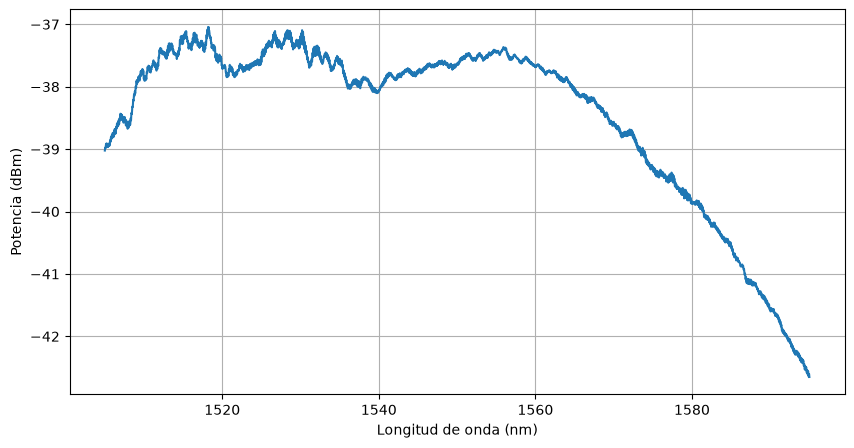

In [10]:
plt.figure(figsize=(10,5))

plt.plot(
    trace.wavelength_nm,
    trace.power_dbm
)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Potencia (dBm)")
plt.grid(True)

In [10]:
from datetime import datetime

N = 2

for i in range(N):

    print(f"\n========== Sweep {i+1}/{N} ==========")

    try:

        osa.run_sweep(
            trace=1,
            averages=1,
            progress_poll_s=0.5,
            start_delay_s=2.0,
        )

        trace = osa.get_trace(
            trace=1,
            metadata_poll_s=0.2,
            metadata_retries=5,
        )

        filename = (
            f"data/test_{i+1}_"
            f"{datetime.now():%Y%m%d_%H%M%S}.txt"
        )

        trace.save_txt(filename)

        print(f"✓ Saved: {filename}")

    except Exception as e:

        print(f"✗ Sweep {i+1} failed")
        print(e)


========== Sweep 1/2 ==========
Trace 1 activated.
Running single sweep.
Previous trace cleared.
Sweep started.
Sweep progress: 100.0%
Sweep completed.
Waiting for trace metadata
Trace consulting ...
Metadata not ready (1/5)
Trace consulting ...
Metadata available.
Reading trace metadata...
Trace points reported by OSA: 90001
Reading trace power data...
✓ Saved: data/test_1_20260715_104112.txt

========== Sweep 2/2 ==========
Trace 1 activated.
Running single sweep.
Previous trace cleared.
Sweep started.
Sweep progress: 100.0%
Sweep completed.
Waiting for trace metadata
Trace consulting ...
Metadata not ready (1/5)
Trace consulting ...
Metadata available.
Reading trace metadata...
Trace points reported by OSA: 90001
Reading trace power data...
✓ Saved: data/test_2_20260715_104711.txt


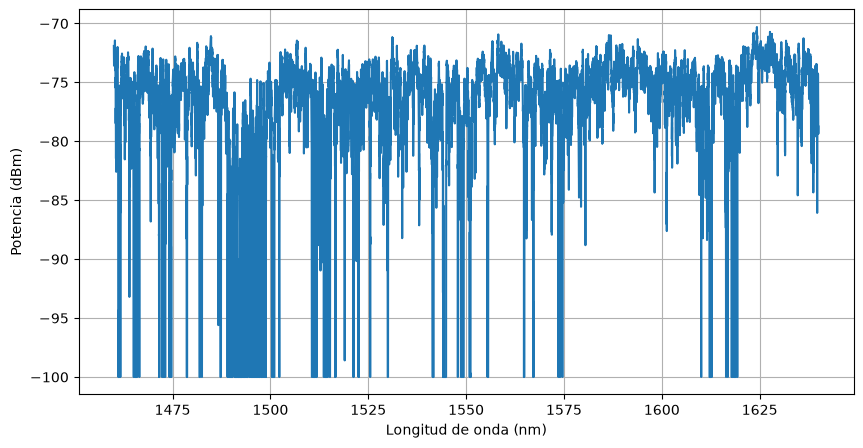

In [9]:
plt.figure(figsize=(10,5))

plt.plot(
    trace.wavelength_nm,
    trace.power_dbm
)

plt.xlabel("Longitud de onda (nm)")
plt.ylabel("Potencia (dBm)")
plt.grid(True)

Este codigo lo probamos con la esperanza de corregir el error de que la lectura no estaba disponible al momento de hacer la lectura.

In [ ]:
osa.run_sweep(
trace=1,
averages=1,
progress_poll_s=0.5,
start_delay_s=2.0,
)

time.sleep(2)

trace = osa.get_trace(1)

Trace 1 activated.
Running single sweep.
Previous trace cleared.
Sweep started.
Sweep progress: 100.0%
Sweep completed.
Reading trace metadata...


VisaIOError: VI_ERROR_TMO (-1073807339): Timeout expired before operation completed.

In [21]:
osa.close()